# Implementing VGG(Visual Geometry Group)-CNN architecture

* using a subset of Food101 dataset containing three classes(pizza, steak, sushi)
* author: Amal Varghese
* github: codewizard-2004

VGG-16 is a convolutional neural network (CNN) architecture known for its simplicity and uniform structure, consisting of 16 layers with weights. It uses small 3x3 convolutional filters throughout, with five max-pooling layers to downsample the spatial dimensions. The network has a fixed input size of 224x224 pixels and concludes with three fully connected layers, with the final one having 1000 neurons for classification based on the ImageNet dataset.

![vgg architecture](https://github.com/codewizard-2004/PyTorch-Image-Recognition/blob/master/images/vgg.jpg?raw=1)

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

2.9.0+cu126
True
12.6
cuda


### Loading the small custom dataset

* get dataset with 3 classes(pizza, steak, sushi) in zip file
* fetching all utility functions
* extracting the loaded data from zip

In [2]:
!wget -O foodvision-mini.zip "https://github.com/codewizard-2004/PyTorch-Image-Recognition/raw/refs/heads/master/data/pizza_steak_sushi40.zip"
!mkdir -p utils
!wget -O utils/data_setup.py "https://raw.githubusercontent.com/codewizard-2004/PyTorch-Image-Recognition/refs/heads/master/utils/data_setup.py"
!wget -O utils/display.py "https://raw.githubusercontent.com/codewizard-2004/PyTorch-Image-Recognition/refs/heads/master/utils/display.py"
!wget -O utils/model_utils.py "https://raw.githubusercontent.com/codewizard-2004/PyTorch-Image-Recognition/refs/heads/master/utils/model_utils.py"
!wget -O utils/process.py "https://raw.githubusercontent.com/codewizard-2004/PyTorch-Image-Recognition/refs/heads/master/utils/process.py"

import zipfile

zip_path = "foodvision-mini.zip"
extract_path = "pizza_steak_sushi"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

--2025-12-08 03:19:38--  https://github.com/codewizard-2004/PyTorch-Image-Recognition/raw/refs/heads/master/data/pizza_steak_sushi.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/codewizard-2004/PyTorch-Image-Recognition/refs/heads/master/data/pizza_steak_sushi.zip [following]
--2025-12-08 03:19:39--  https://raw.githubusercontent.com/codewizard-2004/PyTorch-Image-Recognition/refs/heads/master/data/pizza_steak_sushi.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 63597725 (61M) [application/zip]
Saving to: ‘foodvision-mini.zip’

foodvision-mini.zip 100%[===================>]  60.65M   33

### Implementing
* Transforms
* Dataset
* DataLoader

In [9]:
from torchvision import transforms

mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225] # Normalized to ImageNet mean/standard deviation

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

print(f"Train Transform: {train_transform}")
print(f"Test Transform: {test_transform}")

Train Transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Test Transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [10]:
from torchvision.datasets import ImageFolder
from pathlib import Path

train_dir = Path("./pizza_steak_sushi/pizza_steak_sushi/train")
test_dir = Path("./pizza_steak_sushi/pizza_steak_sushi/test")

train_dataset = ImageFolder(
    root = train_dir,
    transform = train_transform

)

test_dataset = ImageFolder(
    root = test_dir,
    transform = test_transform
)

print(f"Number of images in train dataset: {len(train_dataset)}")
print(f"Number of images in test dataset: {len(test_dataset)}")
classes = train_dataset.classes
print(f"Number of classes: {len(classes)}")
image, label = train_dataset[0]
print(f"Image Shape: {image.shape} -> [color channels, height, width]")

Number of images in train dataset: 960
Number of images in test dataset: 240
Number of classes: 3
Image Shape: torch.Size([3, 224, 224]) -> [color channels, height, width]


In [11]:
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=os.cpu_count()
)

test_dataloader = DataLoader(
    dataset = test_dataset,
    batch_size=BATCH_SIZE,
    shuffle = False,
    num_workers=os.cpu_count()
)

print(train_dataloader)
print(test_dataloader)

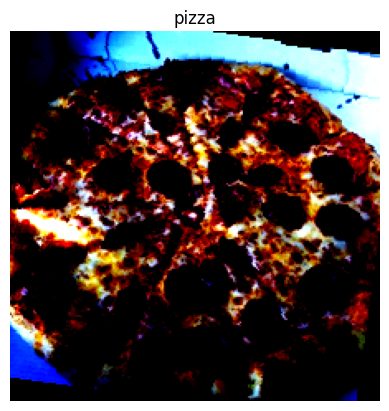

In [13]:
from utils.display import plot_random_images, plot_image

plot_image(image, classes[label])

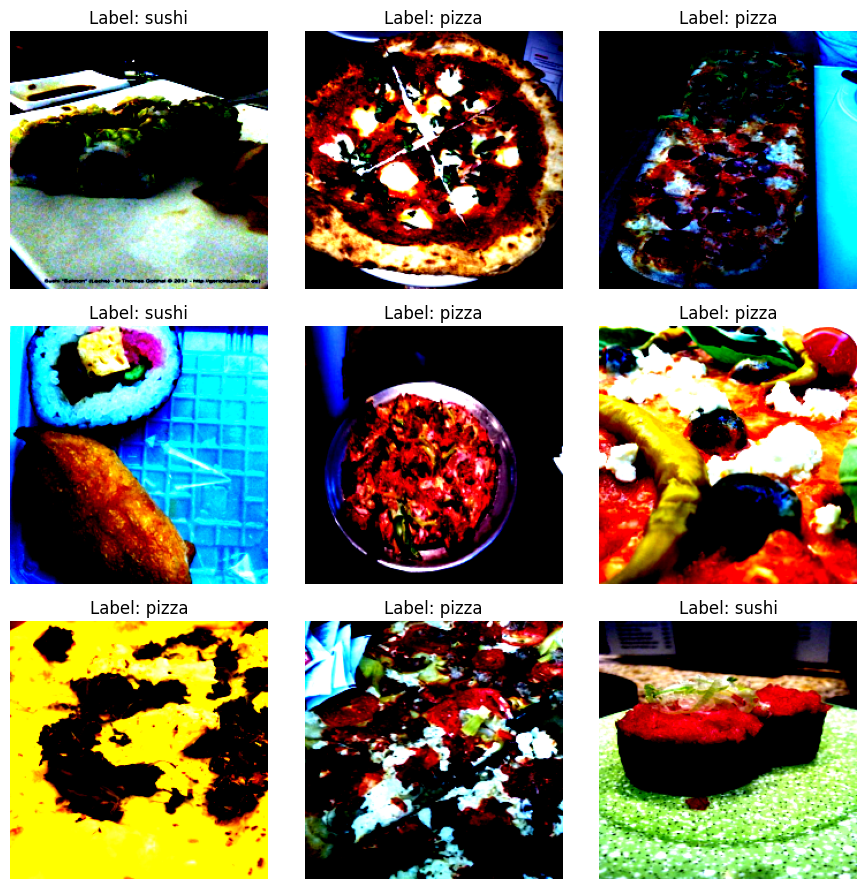

In [14]:
plot_random_images(test_dataset, 9, 42)

## Building the VGG16 model

In [18]:
from torch import nn

class VGG16(nn.Module):
    """
    VGG-16 implementation compatible with 224x224 inputs.
    - Accepts num_classes at init.
    - Uses AdaptiveAvgPool2d((7,7)) to ensure the classifier receives 7x7 feature maps.
    - Properly flattens feature maps before the classifier.
    - Includes a small weight initialization routine.
    """
    def __init__(self, num_classes: int):
        super().__init__()

        # Part A: convolutional feature extractor (5 blocks)
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Part B:
        # With 224x224 input the sequence above yields 7x7; adaptive pooling guarantees it.
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        # --- Part C: classifier head (replace final 1000-class head) ---
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, num_classes)
        )

        # Initialize weights sensibly
        self._init_weights()

    def forward(self, x):
        """
        Forward pass:
          features -> adaptive_pool -> flatten -> classifier
        """
        x = self.features(x)                 # -> (B, 512, H, W), normally H=W=7 for 224 input
        x = self.adaptive_pool(x)            # force 7x7
        x = torch.flatten(x, start_dim=1)    # -> (B, 512*7*7)
        x = self.classifier(x)               # -> (B, num_classes)
        return x

    def _init_weights(self):
        """
        Kaiming initialization for conv layers, normal init for linear layers
        (similar to torchvision/vgg implementation).
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

model_0 = VGG16(3).to(device)


In [19]:
try:
  from torchinfo import summary
except:
  print("Installing torchinfo")
  !pip install torchinfo
  from torchinfo import summary

summary(model_0)

Layer (type:depth-idx)                   Param #
VGG16                                    --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       1,792
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       36,928
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
│    └─Conv2d: 2-6                       73,856
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       147,584
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
│    └─Conv2d: 2-11                      295,168
│    └─ReLU: 2-12                        --
│    └─Conv2d: 2-13                      590,080
│    └─ReLU: 2-14                        --
│    └─Conv2d: 2-15                      590,080
│    └─ReLU: 2-16                        --
│    └─MaxPool2d: 2-17                   --
│    └─Conv2d: 2-18                      1,180,160
│    └─ReLU: 2-19                

### Creating a loss function and optimizer

In [25]:
loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model_0.parameters(),
    lr=1e-4,
    weight_decay=0.01
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.1
)

### Training the model

In [26]:
from utils.process import run_train_test

result = run_train_test(
    model = model_0,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    device = torch.device(device),
    epochs = 30,
    scheduler = scheduler
)

starting....


  0%|          | 0/30 [00:00<?, ?it/s]

[] Allocated: 3282.86 MB | Reserved: 6846.00 MB
Epoch:0	Train Loss:1.1075	Train Acc:0.3469	Test Loss:1.0974	Test Acc:0.3125
[] Allocated: 4307.72 MB | Reserved: 8614.00 MB
Epoch:1	Train Loss:1.0869	Train Acc:0.3875	Test Loss:1.0978	Test Acc:0.3320
[] Allocated: 4307.72 MB | Reserved: 8614.00 MB
Epoch:2	Train Loss:1.0478	Train Acc:0.4396	Test Loss:1.0607	Test Acc:0.4297
[] Allocated: 4307.72 MB | Reserved: 8614.00 MB
Epoch:3	Train Loss:1.0227	Train Acc:0.4792	Test Loss:1.0369	Test Acc:0.4414
[] Allocated: 4307.72 MB | Reserved: 8614.00 MB
Epoch:4	Train Loss:0.9868	Train Acc:0.5281	Test Loss:0.9229	Test Acc:0.5078
[] Allocated: 4307.72 MB | Reserved: 8614.00 MB
Epoch:5	Train Loss:0.9858	Train Acc:0.5260	Test Loss:0.9871	Test Acc:0.5000
[] Allocated: 4307.72 MB | Reserved: 8614.00 MB
Epoch:6	Train Loss:0.9515	Train Acc:0.5344	Test Loss:0.9438	Test Acc:0.5117
[] Allocated: 4307.72 MB | Reserved: 8614.00 MB
Epoch:7	Train Loss:0.9456	Train Acc:0.5437	Test Loss:0.9604	Test Acc:0.5078
[] Alloc

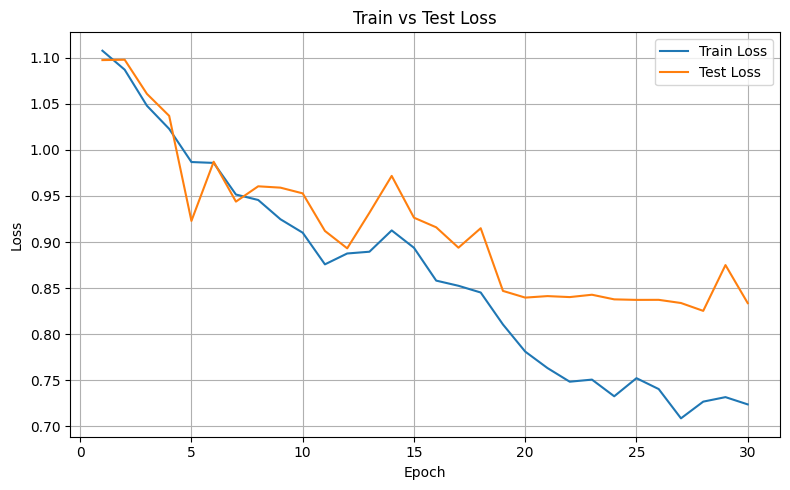

{'train_loss': [1.107535707950592, 1.086949853102366, 1.0478407502174378, 1.022738645474116, 0.9867657820383707, 0.9858164310455322, 0.9515110929807027, 0.9456001440684001, 0.924694569905599, 0.9101028958956401, 0.875754193464915, 0.8875454922517141, 0.889464412132899, 0.9125773886839549, 0.893746155500412, 0.8581101218859355, 0.8525103827317556, 0.8452072858810424, 0.8105311075846354, 0.7811115344365438, 0.7632564167181651, 0.7484407246112823, 0.7507146785656611, 0.7326239913702011, 0.752260555823644, 0.7404391606648763, 0.708693594733874, 0.7268167674541474, 0.7317065318425496, 0.7238169928391774], 'train_acc': [0.346875, 0.3875, 0.4395833333333333, 0.4791666666666667, 0.528125, 0.5260416666666666, 0.534375, 0.54375, 0.55, 0.5635416666666667, 0.58125, 0.59375, 0.5729166666666666, 0.578125, 0.6072916666666667, 0.6145833333333334, 0.615625, 0.60625, 0.6510416666666666, 0.6614583333333334, 0.6625, 0.675, 0.66875, 0.6895833333333333, 0.6583333333333333, 0.6729166666666667, 0.682291666666

In [31]:
from utils.display import plot_train_vs_test_loss, compare_test_accuracy
plot_train_vs_test_loss(result)
print(result)

### Training a model with WAdam optimizer

In [29]:
model_1 = VGG16(3).to(device)
optimizer2 = torch.optim.AdamW(model_1.parameters(), lr=1e-4, weight_decay=1e-3)

result2 = run_train_test(
    model = model_1,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer2,
    loss_fn = loss_fn,
    device = torch.device(device),
    epochs = 30,
    scheduler = scheduler
)


starting....


  0%|          | 0/30 [00:00<?, ?it/s]

[] Allocated: 6893.41 MB | Reserved: 10386.00 MB
Epoch:0	Train Loss:1.1028	Train Acc:0.3646	Test Loss:1.0861	Test Acc:0.3438
[] Allocated: 8436.29 MB | Reserved: 13042.00 MB
Epoch:1	Train Loss:1.0287	Train Acc:0.4906	Test Loss:0.9641	Test Acc:0.4688
[] Allocated: 8436.29 MB | Reserved: 13042.00 MB
Epoch:2	Train Loss:0.9614	Train Acc:0.5479	Test Loss:0.9180	Test Acc:0.5508
[] Allocated: 8436.29 MB | Reserved: 13042.00 MB
Epoch:3	Train Loss:0.8710	Train Acc:0.6000	Test Loss:0.8861	Test Acc:0.5938
[] Allocated: 8436.29 MB | Reserved: 13042.00 MB
Epoch:4	Train Loss:0.8586	Train Acc:0.6062	Test Loss:0.9025	Test Acc:0.5312
[] Allocated: 8436.29 MB | Reserved: 13042.00 MB
Epoch:5	Train Loss:0.8386	Train Acc:0.6167	Test Loss:0.8716	Test Acc:0.6094
[] Allocated: 8436.29 MB | Reserved: 13042.00 MB
Epoch:6	Train Loss:0.8027	Train Acc:0.6344	Test Loss:0.8807	Test Acc:0.5977
[] Allocated: 8436.29 MB | Reserved: 13042.00 MB
Epoch:7	Train Loss:0.7812	Train Acc:0.6500	Test Loss:0.8844	Test Acc:0.6055


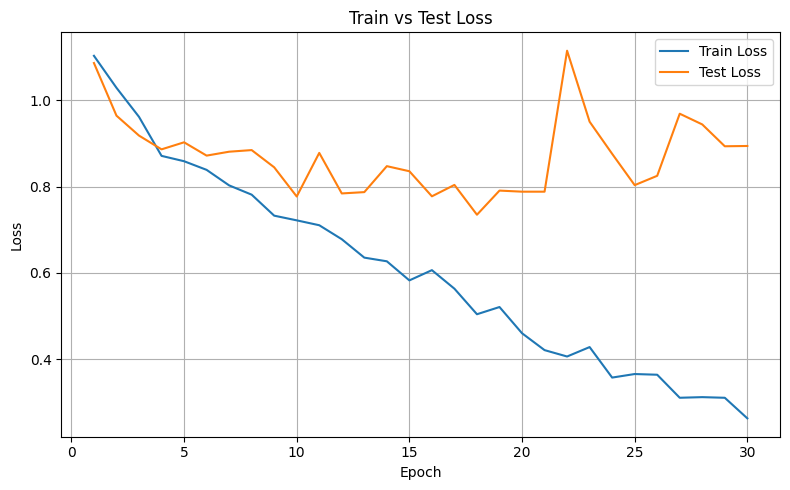

In [30]:
plot_train_vs_test_loss(result2)

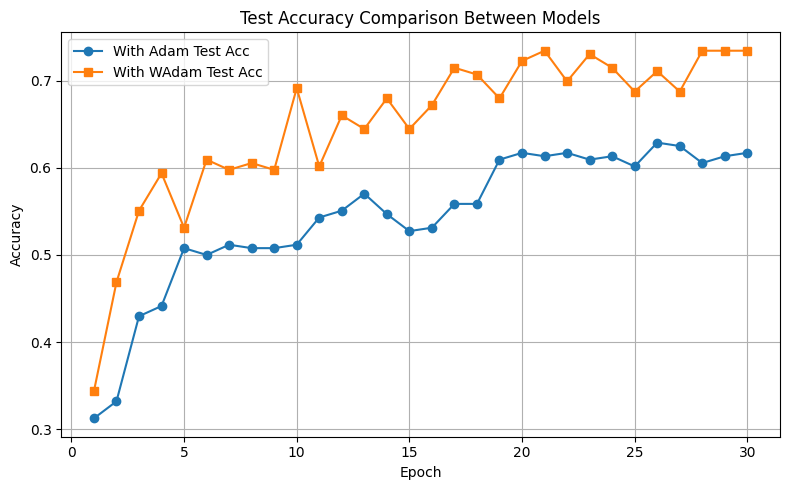

In [32]:
compare_test_accuracy(result, result2, "With Adam", "With WAdam")

## Increasing dataset
* to 600 images per class
* 480 training images
* 120 testing images

In [35]:
!wget -O foodvision-mini60.zip "https://github.com/codewizard-2004/PyTorch-Image-Recognition/raw/refs/heads/master/data/pizza_steak_sushi60.zip"

--2025-12-08 05:10:51--  https://github.com/codewizard-2004/PyTorch-Image-Recognition/raw/refs/heads/master/data/pizza_steak_sushi60.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/codewizard-2004/PyTorch-Image-Recognition/refs/heads/master/data/pizza_steak_sushi60.zip [following]
--2025-12-08 05:10:51--  https://raw.githubusercontent.com/codewizard-2004/PyTorch-Image-Recognition/refs/heads/master/data/pizza_steak_sushi60.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 94797315 (90M) [application/zip]
Saving to: ‘foodvision-mini60.zip’

foodvision-mini60.z 100%[===================>]  90.

Extracting the new data

In [36]:
import zipfile

zip_path = "foodvision-mini60.zip"
extract_path = "pizza_steak_sushi60"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

Creating New Dataset

In [37]:
from torchvision.datasets import ImageFolder
from pathlib import Path

train_dir2 = Path("./pizza_steak_sushi60/train")
test_dir2 = Path("./pizza_steak_sushi60/test")

train_dataset2 = ImageFolder(
    root = train_dir2,
    transform = train_transform

)

test_dataset2 = ImageFolder(
    root = test_dir2,
    transform = test_transform
)

print(f"Number of images in train dataset: {len(train_dataset2)}")
print(f"Number of images in test dataset: {len(test_dataset2)}")
classes = train_dataset.classes
print(f"Number of classes: {len(classes)}")
image, label = train_dataset[0]
print(f"Image Shape: {image.shape} -> [color channels, height, width]")

Number of images in train dataset: 1440
Number of images in test dataset: 360
Number of classes: 3
Image Shape: torch.Size([3, 224, 224]) -> [color channels, height, width]


Creating new DataLoader

In [39]:
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader60 = DataLoader(
    dataset=train_dataset2,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=os.cpu_count()
)

test_dataloader60 = DataLoader(
    dataset = test_dataset2,
    batch_size=BATCH_SIZE,
    shuffle = False,
    num_workers=os.cpu_count()
)

print(train_dataloader60)
print(test_dataloader60)

In [40]:
model_2 = VGG16(3).to(device)
optimizer2 = torch.optim.AdamW(model_2.parameters(), lr=1e-4, weight_decay=1e-3)

result2 = run_train_test(
    model = model_2,
    train_dataloader = train_dataloader60,
    test_dataloader = test_dataloader60,
    optimizer = optimizer2,
    loss_fn = loss_fn,
    device = torch.device(device),
    epochs = 30,
    scheduler = scheduler
)


starting....


  0%|          | 0/30 [00:00<?, ?it/s]

[] Allocated: 7920.46 MB | Reserved: 13042.00 MB
Epoch:0	Train Loss:1.0722	Train Acc:0.4236	Test Loss:1.0257	Test Acc:0.4609
[] Allocated: 9459.34 MB | Reserved: 14810.00 MB
Epoch:1	Train Loss:0.9526	Train Acc:0.5278	Test Loss:0.9325	Test Acc:0.5156
[] Allocated: 9459.34 MB | Reserved: 14810.00 MB
Epoch:2	Train Loss:0.9022	Train Acc:0.5715	Test Loss:0.8870	Test Acc:0.6354
[] Allocated: 9459.34 MB | Reserved: 14810.00 MB
Epoch:3	Train Loss:0.8783	Train Acc:0.5868	Test Loss:0.8163	Test Acc:0.6406
[] Allocated: 9459.34 MB | Reserved: 14810.00 MB
Epoch:4	Train Loss:0.8083	Train Acc:0.6139	Test Loss:0.7399	Test Acc:0.6849
[] Allocated: 9459.34 MB | Reserved: 14810.00 MB
Epoch:5	Train Loss:0.7587	Train Acc:0.6660	Test Loss:0.7783	Test Acc:0.6120
[] Allocated: 9459.34 MB | Reserved: 14810.00 MB
Epoch:6	Train Loss:0.7505	Train Acc:0.6833	Test Loss:0.9039	Test Acc:0.5729
[] Allocated: 9459.34 MB | Reserved: 14810.00 MB
Epoch:7	Train Loss:0.7367	Train Acc:0.6931	Test Loss:0.6975	Test Acc:0.6901


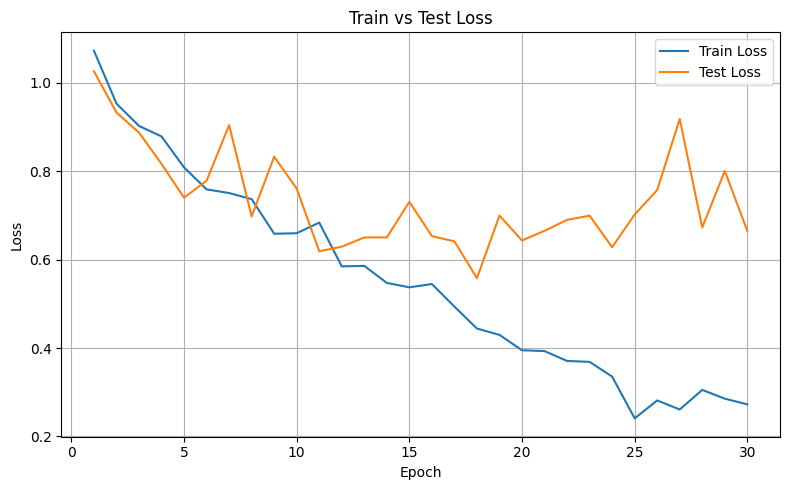

In [45]:
plot_train_vs_test_loss(result2)

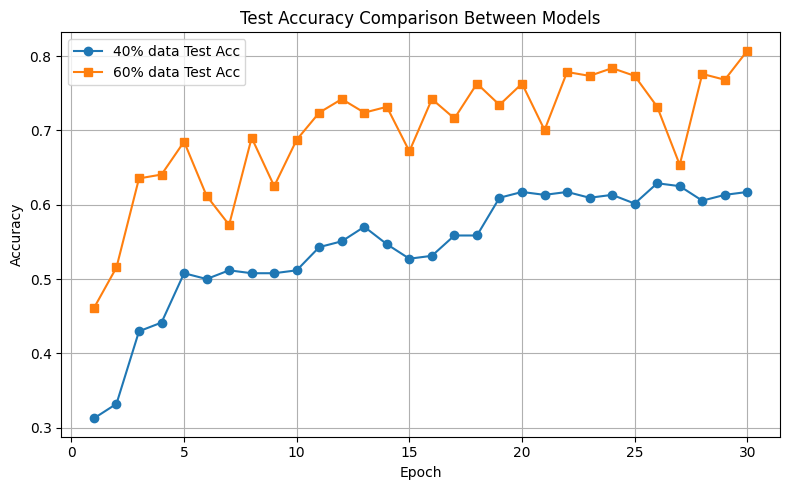

In [46]:
compare_test_accuracy(result, result2, "40% data", "60% data")

In [59]:
def get_model_final_result(result: dict[str ,float])->dict[str, float]:
    model_result = {}

    for i in result:
        if i == "time":
            model_result[i] = result[i]
        else:
            model_result[i] = result[i][-1]

    return model_result

print(get_model_final_result(result2))

{'train_loss': 0.2726240850157208, 'train_acc': 0.8895833333333333, 'test_loss': 0.6650599042574564, 'test_acc': 0.8072916666666666, 'time': 761.1734268665314}


## Making Predictions

In [50]:
from utils.model_utils import make_prediction, save_model

def analyze_model(model: torch.nn.Module,train_dataset, classes: list ,device: str):
  correct = 0
  wrong = 0
  inf_time = 0
  for data in train_dataset:
    prediction, conf, inf = make_prediction(model, data,classes, torch.device(device))
    if prediction == classes[data[1]]:
      correct += 1
    else:
      wrong += 1
    inf_time += inf

  print(f"total: {correct+wrong}")
  print(f"correct: {correct}")
  print(f"Incorrect: {wrong}")
  print(f"Correct percent: {(correct*100)/(correct+wrong)}")
  print(f"average inference time: {inf_time/(correct+wrong)}")


analyze_model(model_0, train_dataset, classes, torch.device(device))

total: 960
correct: 681
Incorrect: 279
Correct percent: 70.9375
average inference time: 1.6418958333333342


In [51]:
analyze_model(model_1,train_dataset, classes, torch.device(device))

total: 960
correct: 889
Incorrect: 71
Correct percent: 92.60416666666667
average inference time: 1.576636458333334


In [52]:
analyze_model(model_2,train_dataset2, classes, torch.device(device))

total: 1440
correct: 1348
Incorrect: 92
Correct percent: 93.61111111111111
average inference time: 1.613531944444446


## saving the model

In [53]:
!mkdir -p models
dest = Path("./models")
dest.exists()

True

In [55]:
from utils.model_utils import save_model

metadata = {
    "arch": "VGG16",
    "desc": "Visual Geometry Group architecture with trivial transform augementation for 224x224 images.\nIt can predict three classes (pizza, steak, sushi)",
    "train_acc": round(result2["train_acc"][-1]*100, 2),
    "training_images": len(train_dataset),
    "parameters":sum(p.numel() for p in model_2.parameters())
}

save_model(
    model = model_2,
    metadata = metadata,
    name = "VGG16",
    loc = dest,
    device = torch.device(device)
)

model saved at models/VGG16.pt


### save the entire model

In [57]:
torch.save(model_2, dest/"VGG16_full.pth")

### saving the state_dict

In [58]:
torch.save(model_2.state_dict(), dest/"VGG16_state_dict_full.pth")